# 1. Entendimiento del problema

Garment Industry es una compañia del sector textil con muchas actividades manuales. Su exito está en que las prendas son "hechas a mano", por lo que medir la productividad de sus empleados se vuelve esencial para mejorar las utilidades de la organización. Es por esto que la compañía quiere estimar los niveles de productividad de sus empleados para mejorar la operación y mantener los ingresos esperados, ademas identificar herramientas para mejorar el dia a dia de sus empleados

# 2. Enfoque analítico

Construir un modelo de regresión para predecir la productividad de cada empleado con un MAPE menor al 20% (Probabilidad superior al 80%)

# 3. Requerimientos de Datos
- Se requieren datos del trabajador en su puesto de trabajo particular.
- Se requieren mediciones del puesto de trabajo (tiempos, cantidad de prendas, momentos de ocio, cantidad de personas).
- Se requiere una medición inicial de la productividad.

# 4. Recolección de Datos
- date: Fecha de medición de la productividad.
- quarter: Trimestre de la medición.
- department: Area de trabajo en particular.
- day: Nombre del dia en el que se hizo la medición.
- team: Numero del equipo de trabajo.
- target_productivity: Productividad objetivo del area de trabajo.
- smv: Valor de tiempo estandar en minutos de la actividad.
- wip: Cantidad de trabajo en proceso (unidades).
- over_time: Tiempo en general de operación.
- incentive: Porcentaje de incentivos al área de trabajo.
- idle_time: Tiempo de parada.
- idle_men: Cantidad de trabajadores quieros en el tiempo de parada.
- no_of_style_change: Cantidad de cambios de estilo en la producción.
- no_of_workers: Cantidad total de trabajadores.
- actual_productivity: Productividad actual (**Y**).

In [1]:
import pandas as pd
import numpy as np
import warnings

warnings.filterwarnings("ignore")

data = pd.read_csv('garments_worker_productivity.csv')
data

,date,quarter,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,1/1/2015,Quarter1,sweing,Thursday,8,0.80,26.16,1108.0,7080,98,0.0,0,0,59.0,0.940725
1,1/1/2015,Quarter1,finishing,Thursday,1,0.75,3.94,NaN,960,0,0.0,0,0,8.0,0.886500
2,1/1/2015,Quarter1,sweing,Thursday,11,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
3,1/1/2015,Quarter1,sweing,Thursday,12,0.80,11.41,968.0,3660,50,0.0,0,0,30.5,0.800570
4,1/1/2015,Quarter1,sweing,Thursday,6,0.80,25.90,1170.0,1920,50,0.0,0,0,56.0,0.800382
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1192,3/11/2015,Quarter2,finishing,Wednesday,10,0.75,2.90,NaN,960,0,0.0,0,0,8.0,0.628333
1193,3/11/2015,Quarter2,finishing,Wednesday,8,0.70,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1194,3/11/2015,Quarter2,finishing,Wednesday,7,0.65,3.90,NaN,960,0,0.0,0,0,8.0,0.625625
1195,3/11/2015,Quarter2,finishing,Wednesday,9,0.75,2.90,NaN,1800,0,0.0,0,0,15.0,0.505889


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1197 entries, 0 to 1196
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   1197 non-null   object 
 1   quarter                1197 non-null   object 
 2   department             1197 non-null   object 
 3   day                    1197 non-null   object 
 4   team                   1197 non-null   int64  
 5   targeted_productivity  1197 non-null   float64
 6   smv                    1197 non-null   float64
 7   wip                    691 non-null    float64
 8   over_time              1197 non-null   int64  
 9   incentive              1197 non-null   int64  
 10  idle_time              1197 non-null   float64
 11  idle_men               1197 non-null   int64  
 12  no_of_style_change     1197 non-null   int64  
 13  no_of_workers          1197 non-null   float64
 14  actual_productivity    1197 non-null   float64
dtypes: f

# 5. Entendimiento de los Datos
- Conocer nuestra variable y
- Identificar datos nulos
- Analisis univariado y multivariado

In [6]:
import matplotlib.pyplot as plt
import seaborn as sb

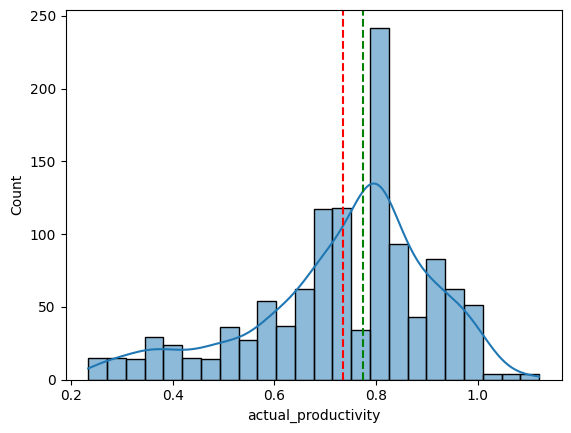

In [8]:
sb.histplot(data = data, x = 'actual_productivity', kde = True)
plt.axvline(x = data['actual_productivity'].mean(), color = 'red', linestyle = 'dashed')
plt.axvline(x = data['actual_productivity'].median(), color = 'green', linestyle = 'dashed')
plt.show()

## Datos nulos

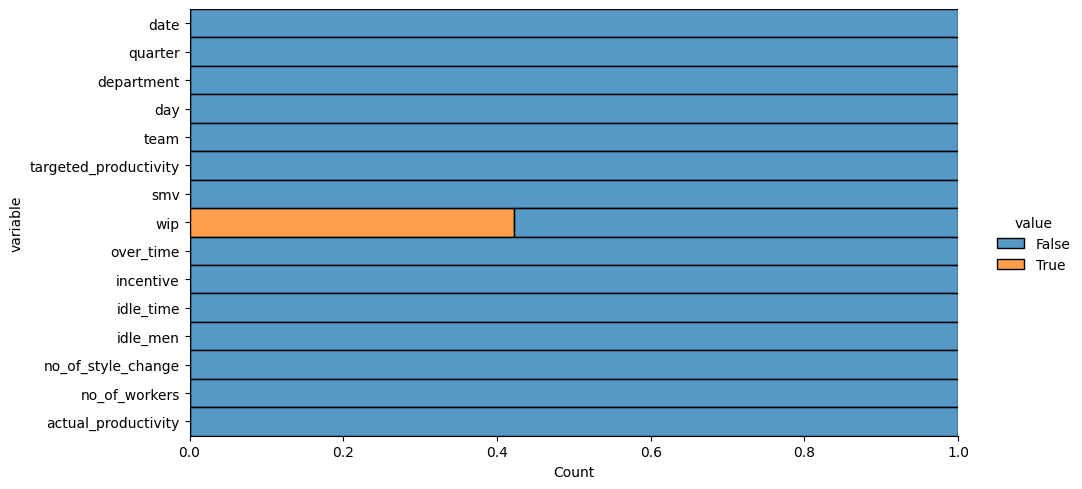

In [9]:
#Visualizar la proporción de datos nulos por variable
data.isnull().melt().pipe(lambda df: sb.displot(data = df, y = 'variable', hue = 'value', multiple = 'fill', aspect = 2))
plt.show()

## Exploración univariada de los datos

### Variables numericas

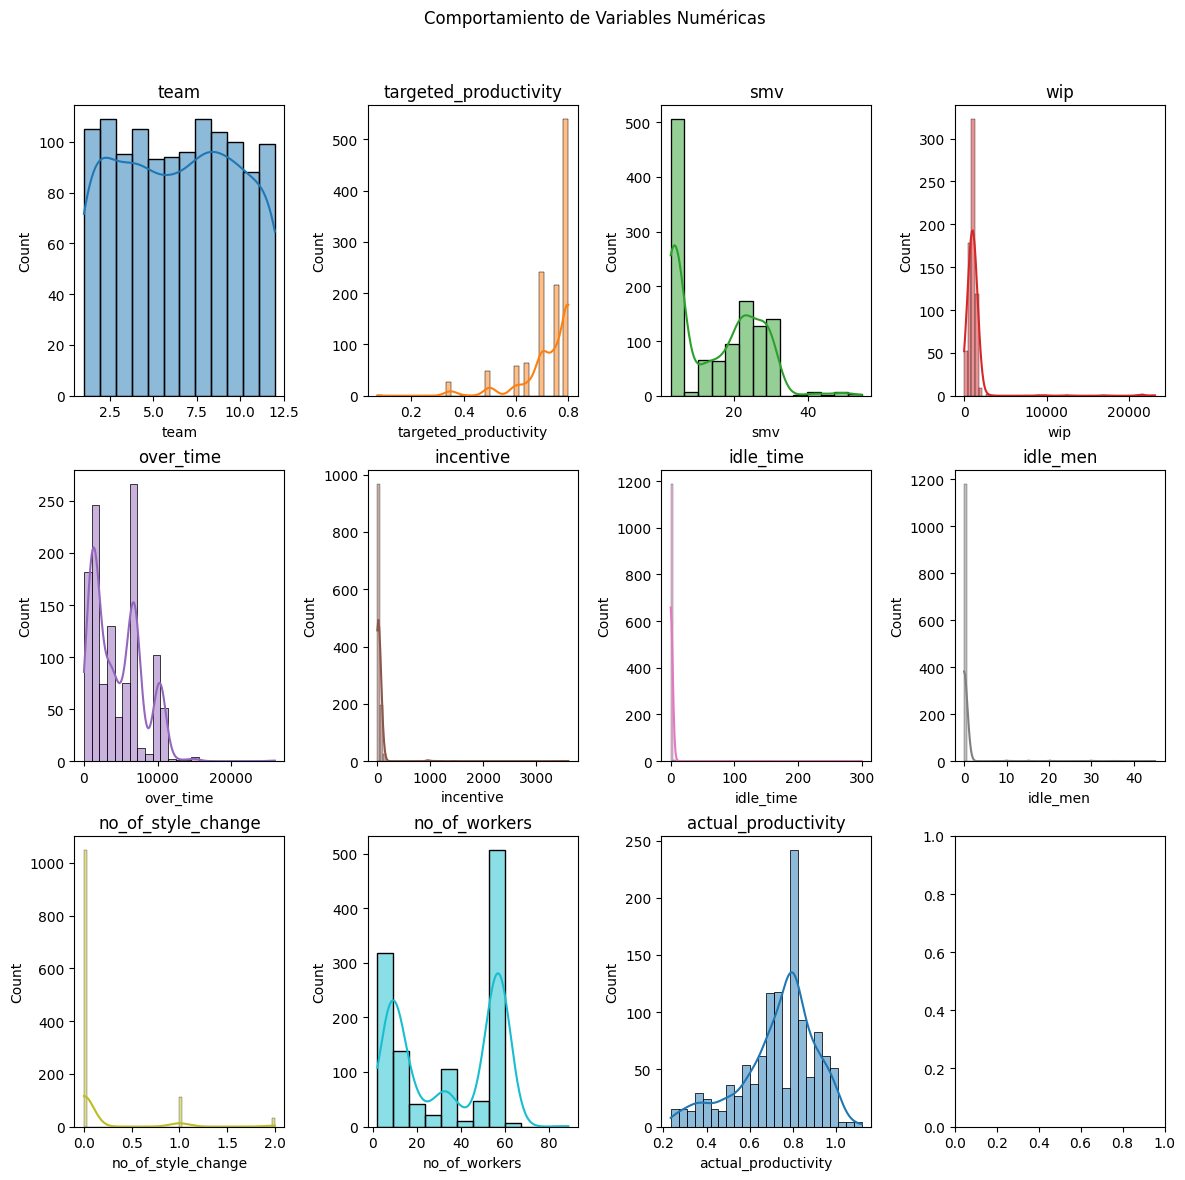

In [11]:
fig, ax = plt.subplots(3, 4, figsize = (12, 12))
ax = ax.flat
num_col = data.select_dtypes(include = ['int64', 'float64']).columns

for i, col in enumerate(num_col):
  sb.histplot(
    data = data,
    x = col, 
    kde = True,
    color = (list(plt.rcParams['axes.prop_cycle']) * 7)[i]['color'],
    ax = ax[i]
  )
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle('Comportamiento de Variables Numéricas')
plt.show()

### Variables categoricas

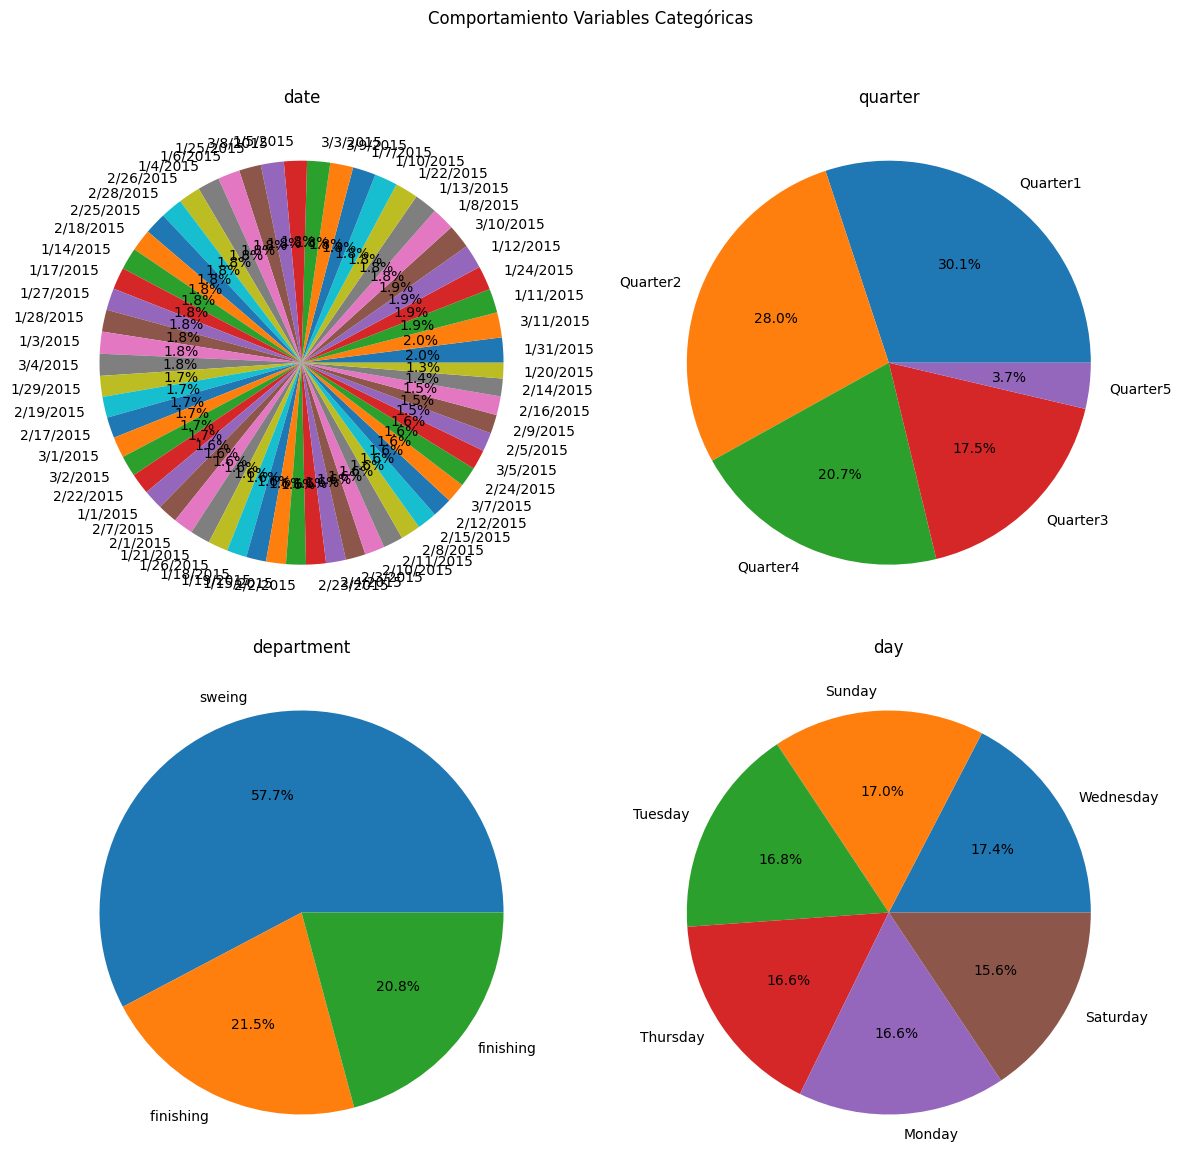

In [13]:
fig, ax = plt.subplots(2, 2, figsize = (12, 12))
ax = ax.flat
cat_col = data.select_dtypes(include = ['object']).columns

for i, col in enumerate(cat_col):
  ax[i].pie(x = data[col].value_counts(), labels = data[col].value_counts().index, autopct = '%0.1f%%')
  ax[i].set_title(col)

fig.tight_layout()
fig.subplots_adjust(top = 0.9)
fig.suptitle("Comportamiento Variables Categóricas")
plt.show()

# TODO: Imputacion de datos nulos por metodo recursivo.